# Snore vs Non‑Snore — **SHAP** + **Grad‑CAM** (Load Pretrained MLP)

This notebook:
- **Loads** your pretrained **MLP** and **scaler** from `/content/drive/MyDrive/snore_models/`
- Keeps the **same noise augmentation** you used (ESC‑50 mixed at random SNR into training waveforms)
- Runs **SHAP** (with `shap.kmeans` background) for the MLP on YAMNet‑stats inputs
- Trains a small **CNN on log‑mel spectrograms** and visualizes **Grad‑CAM** heatmaps

**Tip:** Run cells top‑to‑bottom. You will be prompted to upload `kaggle.json` for dataset download.


In [ ]:
!pip -q install librosa soundfile noisereduce tensorflow_hub tqdm scikit-learn matplotlib seaborn kaggle shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 616.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 924.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00


## Mount Drive & Configure Kaggle

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')
print('Upload kaggle.json (from https://www.kaggle.com/settings/account)')
files.upload();
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive
Upload kaggle.json (from https://www.kaggle.com/settings/account)


Saving kaggle.json to kaggle.json


## Paths & Pretrained Artifacts

In [ ]:
import os
SNORE_DIR = '/content/drive/MyDrive/snore_data'
NOISE_DIR = '/content/drive/MyDrive/noise_data'
MODEL_DIR = '/content/drive/MyDrive/snore_models'
MLP_PATH = os.path.join(MODEL_DIR, 'mlp_yamnet_stat.h5')
SCALER_PATH = os.path.join(MODEL_DIR, 'scaler_yamnet_stat.pkl')
print('Looking for model at:', MLP_PATH)
print('Looking for scaler at:', SCALER_PATH)
print('Model exists?', os.path.exists(MLP_PATH))
print('Scaler exists?', os.path.exists(SCALER_PATH))
if not os.path.exists(MODEL_DIR):
    print('MODEL_DIR not found, listing /content/drive/MyDrive:')
    print(os.listdir('/content/drive/MyDrive'))

Looking for model at: /content/drive/MyDrive/snore_models/mlp_yamnet_stat.h5
Looking for scaler at: /content/drive/MyDrive/snore_models/scaler_yamnet_stat.pkl
Model exists? True
Scaler exists? True


## Download Datasets (Snore + ESC‑50 Noise)

In [ ]:
!mkdir -p '/content/drive/MyDrive/snore_data'
!mkdir -p '/content/drive/MyDrive/noise_data'
!kaggle datasets download tareqkhanemu/snoring -p '/content/drive/MyDrive/snore_data' --unzip
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p '/content/drive/MyDrive/noise_data' --unzip

Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
SNORE_PATH = '/content/drive/MyDrive/snore_data/Snoring Dataset/1'  # class 1
NON_PATH   = '/content/drive/MyDrive/snore_data/Snoring Dataset/0'  # class 0
NOISE_PATH = '/content/drive/MyDrive/noise_data/audio/audio'        # ESC-50 concatenated WAVs
sn = sum(f.lower().endswith('.wav') for f in os.listdir(SNORE_PATH))
ns = sum(f.lower().endswith('.wav') for f in os.listdir(NON_PATH))
nz = sum(f.lower().endswith('.wav') for f in os.listdir(NOISE_PATH))
print('Snore files:', sn, '| Non-snore:', ns, '| Noise wavs:', nz)
assert sn>0 and ns>0 and nz>0, 'Verify dataset paths/downloads.'

Snore files: 500 | Non-snore: 500 | Noise wavs: 2000


## SAME Noise Augmentation for Waveforms

In [ ]:
import numpy as np, librosa, random
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')]
assert len(noise_files)>0

def mix_audio_with_noise(audio, noise, snr_db=10):
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]
    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)

## YAMNet Embeddings → 2048‑D Stats (mean + std)

In [ ]:
import tensorflow as tf, tensorflow_hub as hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
def extract_yamnet_stats_from_waveform(y):
    scores, embeddings, _ = yamnet_model(tf.convert_to_tensor(y, dtype=tf.float32))
    E = embeddings.numpy()  # (T,1024)
    return np.concatenate([E.mean(axis=0), E.std(axis=0)], axis=0)  # (2048,)

## Build Train/Test Split & Extract Features (No Retraining)

In [ ]:
from sklearn.model_selection import train_test_split
snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')]
non_files  = [os.path.join(NON_PATH, f) for f in os.listdir(NON_PATH) if f.lower().endswith('.wav')]
X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))
X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all)
len(X_tr_paths), len(X_te_paths)

(800, 200)

In [ ]:
from tqdm import tqdm
def features_from_paths(paths, add_noise=False):
    feats=[]
    for p in tqdm(paths, desc=f'Extracting (add_noise={add_noise})'):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0)
        feats.append(extract_yamnet_stats_from_waveform(y))
    return np.stack(feats)

# NOTE: For SHAP background we want training distribution; we do not retrain.
X_tr = features_from_paths(X_tr_paths, add_noise=True)
X_te = features_from_paths(X_te_paths, add_noise=False)
X_tr.shape, X_te.shape

Extracting (add_noise=False): 100%|██████████| 200/200 [00:26<00:00,  7.61it/s]


((800, 2048), (200, 2048))

## Load Pretrained MLP & Scaler

In [ ]:
import joblib
from tensorflow.keras.models import load_model

assert os.path.exists(MLP_PATH), f'Missing model file at {MLP_PATH}'
assert os.path.exists(SCALER_PATH), f'Missing scaler file at {SCALER_PATH}'

scaler = joblib.load(SCALER_PATH)
mlp = load_model(MLP_PATH)

X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
X_tr_s.shape, X_te_s.shape

((800, 2048), (200, 2048))

## Evaluate Loaded MLP

              precision    recall  f1-score   support

           0     0.9655    0.8400    0.8984       100
           1     0.8584    0.9700    0.9108       100

    accuracy                         0.9050       200
   macro avg     0.9120    0.9050    0.9046       200
weighted avg     0.9120    0.9050    0.9046       200

ROC-AUC: 0.9841


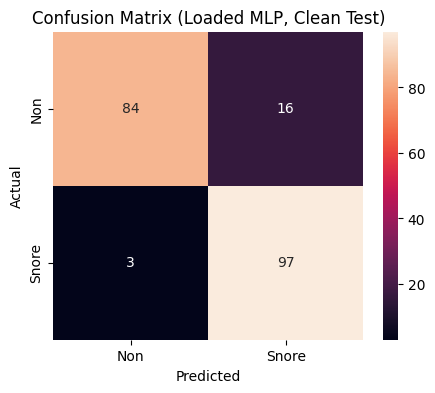

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns
probs = mlp.predict(X_te_s, verbose=0).ravel(); preds = (probs>=0.5).astype(int)
print(classification_report(y_te, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_te, probs))
cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Non','Snore'], yticklabels=['Non','Snore'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Loaded MLP, Clean Test)'); plt.show()

## SHAP on Loaded MLP (with `kmeans` background)

  0%|          | 0/200 [00:00<?, ?it/s]

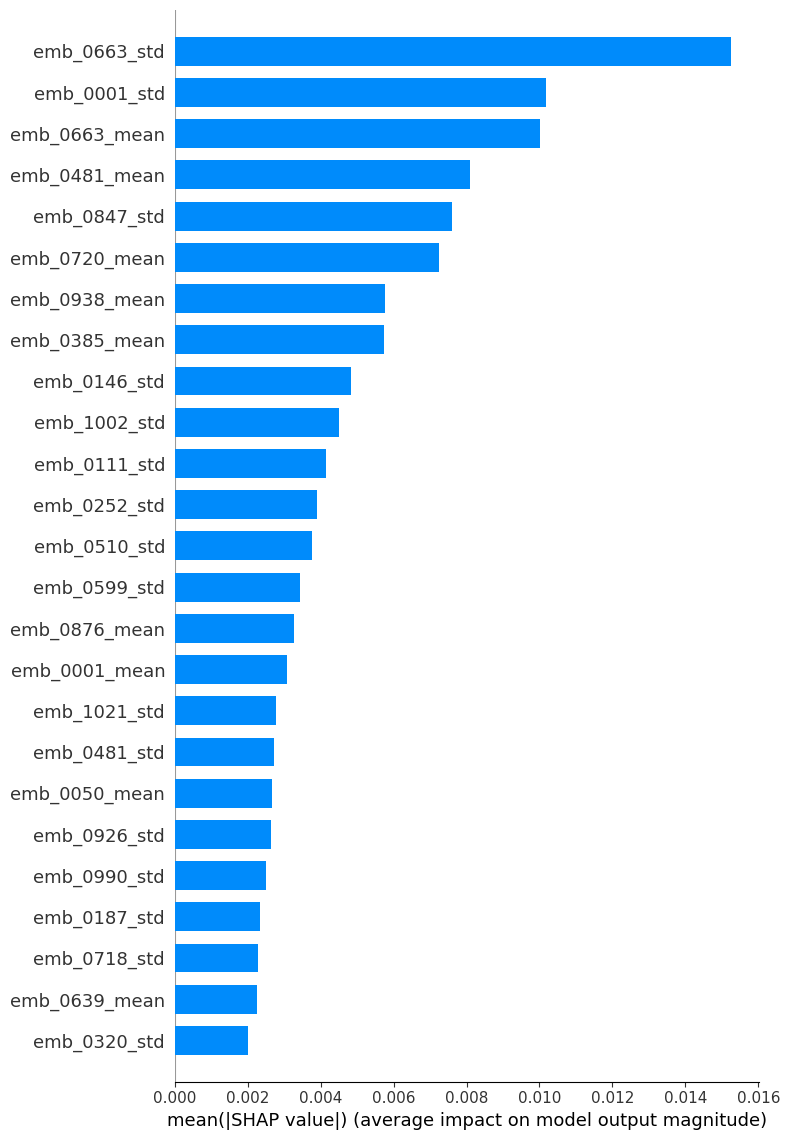

In [ ]:
import shap, numpy as np

# Summarize background with K centroids for speed+stability
background = shap.kmeans(X_tr_s, 20)

def f_predict(x):
    return mlp.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(f_predict, background)
rng = np.random.default_rng(42)
explain_idx = rng.choice(X_te_s.shape[0], size=min(200, X_te_s.shape[0]), replace=False)
X_explain = X_te_s[explain_idx]
y_explain = y_te[explain_idx]

shap_values = explainer.shap_values(X_explain, nsamples='auto')
shap_values = np.array(shap_values)
if shap_values.ndim == 1:
    shap_values = shap_values.reshape(len(X_explain), -1)
feat_names = [f'emb_{i:04d}_mean' for i in range(1024)] + [f'emb_{i:04d}_std' for i in range(1024)]
shap.summary_plot(shap_values, X_explain, feature_names=feat_names, plot_type='bar', max_display=25)

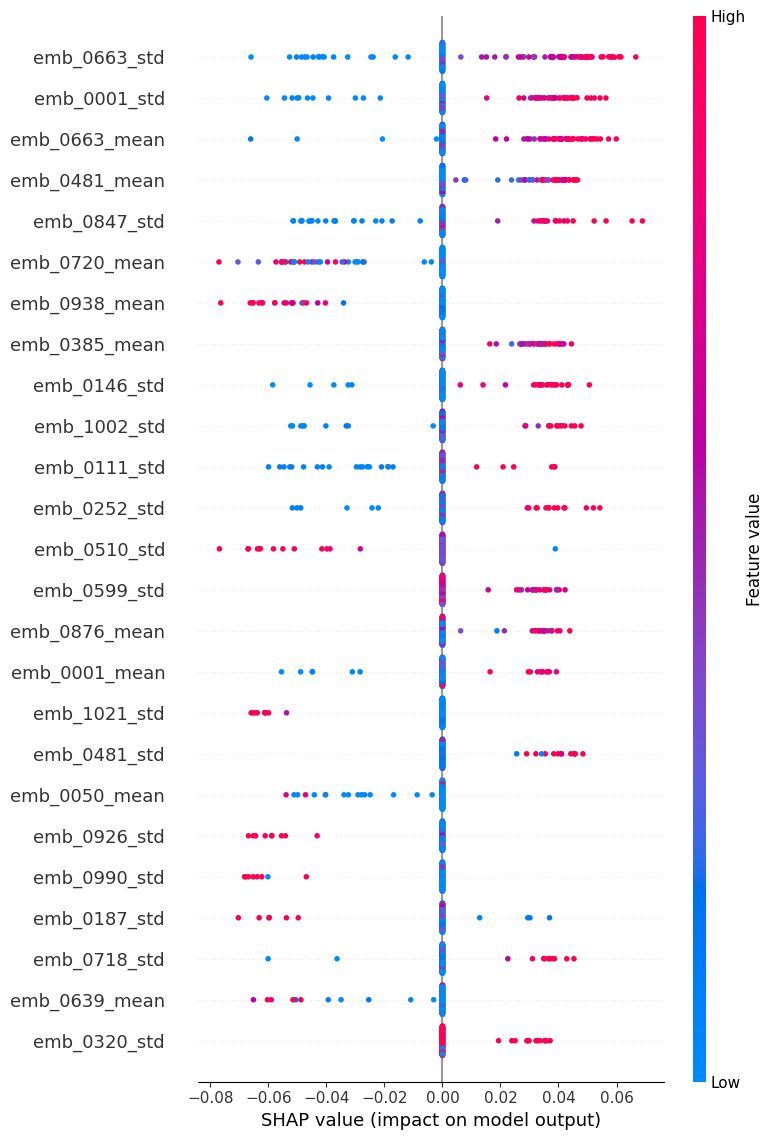

In [ ]:
shap.summary_plot(shap_values, X_explain, feature_names=feat_names, max_display=25)

## Model B: CNN on Log‑Mel Spectrograms (for Grad‑CAM)

In [ ]:
def wav_to_logmelspec(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    logS = librosa.power_to_db(S, ref=np.max)
    return logS  # (n_mels, T)

def specs_from_paths(paths, add_noise=False, sr=16000, target_sec=3.0, n_mels=64):
    X=[]
    for p in paths:
        y = load_with_optional_noise(p, add_noise=add_noise, sr=sr, target_sec=target_sec)
        M = wav_to_logmelspec(y, sr=sr, n_mels=n_mels)
        X.append(M)
    target_t = max(m.shape[1] for m in X)
    Xp=[]
    for M in X:
        if M.shape[1] < target_t:
            pad = target_t - M.shape[1]
            M = np.pad(M, ((0,0),(0,pad)), mode='edge')
        else:
            M = M[:, :target_t]
        Xp.append(M)
    Xp = np.stack(Xp)
    return Xp[..., None]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

Xtr_spec = specs_from_paths(X_tr_paths, add_noise=True)
Xte_spec = specs_from_paths(X_te_paths, add_noise=False)
input_shape = Xtr_spec.shape[1:]
cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
    layers.GlobalAveragePooling2D(name='gap'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
hist_cnn = cnn.fit(Xtr_spec, y_tr, epochs=20, batch_size=32, validation_split=0.15, verbose=1)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.5129 - loss: 1.2843 - val_accuracy: 0.4750 - val_loss: 0.6947
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.5119 - loss: 0.7046 - val_accuracy: 0.4750 - val_loss: 0.6945
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.5481 - loss: 0.6947 - val_accuracy: 0.4750 - val_loss: 0.7005
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.4967 - loss: 0.6972 - val_accuracy: 0.5750 - val_loss: 0.6909
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.5356 - loss: 0.6887 - val_accuracy: 0.4750 - val_loss: 0.7026
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.5043 - loss: 0.6968 - val_accuracy: 0.6500 - val_loss: 0.6831
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.5579 - loss: 0.6861 - val_accuracy: 0.6833 - val_loss: 0.6691
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.6032 - loss: 0.6807 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
probs_cnn = cnn.predict(Xte_spec, verbose=0).ravel(); preds_cnn = (probs_cnn>=0.5).astype(int)
print(classification_report(y_te, preds_cnn, digits=4))
print('ROC-AUC (CNN):', roc_auc_score(y_te, probs_cnn))

              precision    recall  f1-score   support

           0     0.6483    0.9400    0.7673       100
           1     0.8909    0.4900    0.6323       100

    accuracy                         0.7150       200
   macro avg     0.7696    0.7150    0.6998       200
weighted avg     0.7696    0.7150    0.6998       200

ROC-AUC (CNN): 0.8459000000000001
